## <b>Flight Price Prediction </b>

## <b> PROBLEM STATEMENT :</b>

<b><em>Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travellers saying that flight ticket prices are so unpredictable. Here you will be provided with prices of flight tickets for various airlines between the months of March and June of 2019 and between various cities.</em></b>

- <b> Importing require library for performing EDA, Data Wrangling and data cleaning</b>

In [1]:
import pandas as pd # for data wrangling purpose
import numpy as np # Basic computation library
import seaborn as sns # For Visualization 
import matplotlib.pyplot as plt # ploting package
%matplotlib inline
import warnings # Filtering warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing Flight Prediction dataset Excel file using pandas
df = pd.read_excel('Data/Data_Train.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df.shape

(10683, 11)

#### Comment :
- Training dataset contain 10683 rows and 11 columns.
- Our Target variable is **Price**. We gone predict flight prices using **Various Regression Algorithms.**
- Some feature with date and time related columns are mention with object datatype. **We gone convert them into datetime datatype format along with going to perform some feature engineering over them to create few new columns of our interest.**

### Converting Date and time columns from object type to Datetime type ###

In [4]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Arrival_Time']=pd.to_datetime(df['Arrival_Time'])

**1. Feature Engineering on Date of Journey Columns**

In [5]:
# Extracting Day from Date_of_journey column
df['Journey_Day'] = pd.to_datetime(df.Date_of_Journey,format="%d/%m/%Y").dt.day

# Extracting Month from Date_of_journey column
df['Journey_Month'] = pd.to_datetime(df.Date_of_Journey, format="%d/%m/%Y").dt.month

# Dropping Date_of_journey column
df.drop("Date_of_Journey",axis=1,inplace=True)

**2. Feature Engineering on 'Duration' Column**

In [6]:
# Conversion of Duration column from hr & Minutes format to Minutes
df['Duration']=df['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)

# convert this column into a numeric datatypes
df['Duration']=pd.to_numeric(df['Duration'])

**3. Feature Engineering on 'Dep_Time' Column**

In [7]:
# Extracting Hours from Dep_Time column
df['Dep_Hour']=pd.to_datetime(df['Dep_Time']).dt.hour

# Extracting Minutes from Dep_Time column
df['Dep_Min']=pd.to_datetime(df['Dep_Time']).dt.minute

# Dropping Dep_Time column
df.drop("Dep_Time",axis=1,inplace=True)

**4. Feature Engineering on 'Arrival_Time' Column**

In [8]:
# Extracting Arrival_Hour from Arrival_Time column
df['Arrival_Hour']=pd.to_datetime(df['Arrival_Time']).dt.hour

# Extracting Arrival_Min from Arrival_Time column
df['Arrival_Min']=pd.to_datetime(df['Arrival_Time']).dt.minute

# Dropping Arruval_Time column
df.drop("Arrival_Time",axis=1,inplace=True)

In [9]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35


In [10]:
# Spliting data into categorical and Numerical Variable
Numerical = ['Duration', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min']

Categorical = ['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

#### We also need to do some feature engineering on Source and Destination columns, We can see at some place Dehli is mention and other places New Dehli is mention. 
#### First enlist different unique values in categorical variable and afterwards we will perform feature engineering.

In [11]:
for i in Categorical:
    print('Unique value counts of ',i, 'Enlisted as Below Table :')
    print('-'*40)
    print(df[i].value_counts())
    print("*"*120)

Unique value counts of  Airline Enlisted as Below Table :
----------------------------------------
Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
************************************************************************************************************************
Unique value counts of  Source Enlisted as Below Table :
----------------------------------------
Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64
**************************

#### Observation :
- "New Delhi" is mention as "Delhi". We we gone regulated it.
- No info is mention as 'No Info' few times.
- **Very Few Premium economy or Business class flight in dataset. This might be due to high ticket price**

In [12]:
# Replacing "New Delhi" as "Delhi" in Destination column
df["Destination"] = df["Destination"].replace("New Delhi","Delhi")

# In the column "Additional Info", "No Info" and "No info" are same so replacing it by "No Info
df['Additional_Info'] = df['Additional_Info'].replace("No info", "No Info")

In [13]:
df.Total_Stops.unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [14]:
df.Total_Stops=df.Total_Stops.replace({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4})

In [15]:
df.isnull().sum()

Airline            0
Source             0
Destination        0
Route              1
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
Journey_Day        0
Journey_Month      0
Dep_Hour           0
Dep_Min            0
Arrival_Hour       0
Arrival_Min        0
dtype: int64

In [16]:
df.dropna(inplace=True)

### Data Integrity Check

<b> Since dataset is large, Let check for any entry which is repeated or duplicated in dataset. </b>

In [17]:
df.duplicated().sum()  # This will check the duplicate data for all columns.

np.int64(222)

**Around 222 duplicate data rows. It huge and we gone drop them. There is no point on training model on duplicated data.**

In [18]:
df.drop_duplicates(keep='last',inplace= True)

In [19]:
df.shape

(10460, 14)

<b> Let check if any whitespace, 'NA' or '-' exist in dataset. </b>

In [20]:
df.isin([' ','NA','-','?']).sum().any()

np.False_

## Exploring Features Source

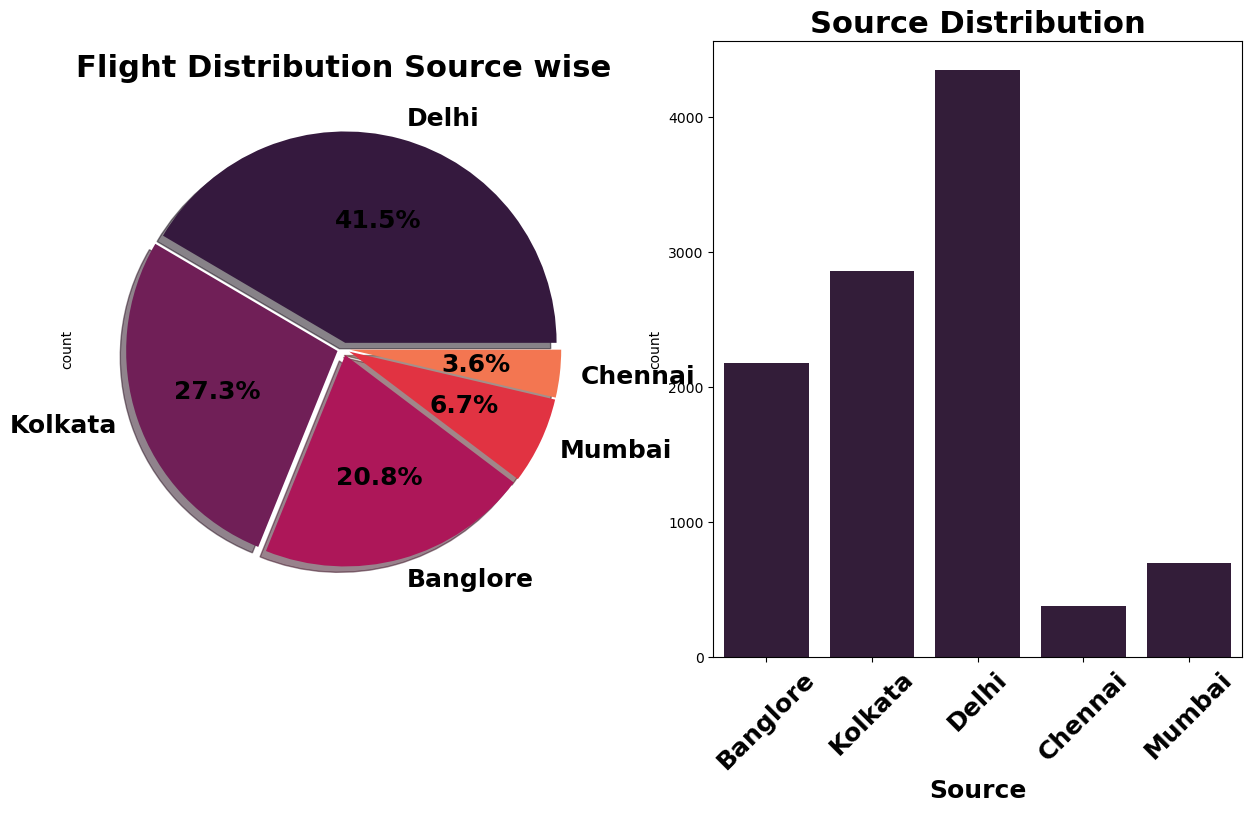

In [21]:
plt.figure(figsize=(15,8))
sns.set_palette('rocket')
plt.subplot(1,2,1)
df['Source'].value_counts().plot.pie(explode=[0.03,0.03,0.03,0.03,0.03],autopct='%3.1f%%',
                                          textprops ={ 'fontweight': 'bold','fontsize':18},shadow=True)
plt.title('Flight Distribution Source wise', fontsize=22,fontweight ='bold')

plt.subplot(1,2,2)
sns.countplot(x='Source',data=df)
plt.title('Source Distribution',fontsize=22,fontweight ='bold')
plt.xlabel("Source",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=18,fontweight ='bold',rotation=45)
plt.show()

#### Observation :
- **Maximum flight depart from Delhi followed by Kolkata.**

#### Let Explore Source With respect to Target Variable

## Destination VS Price

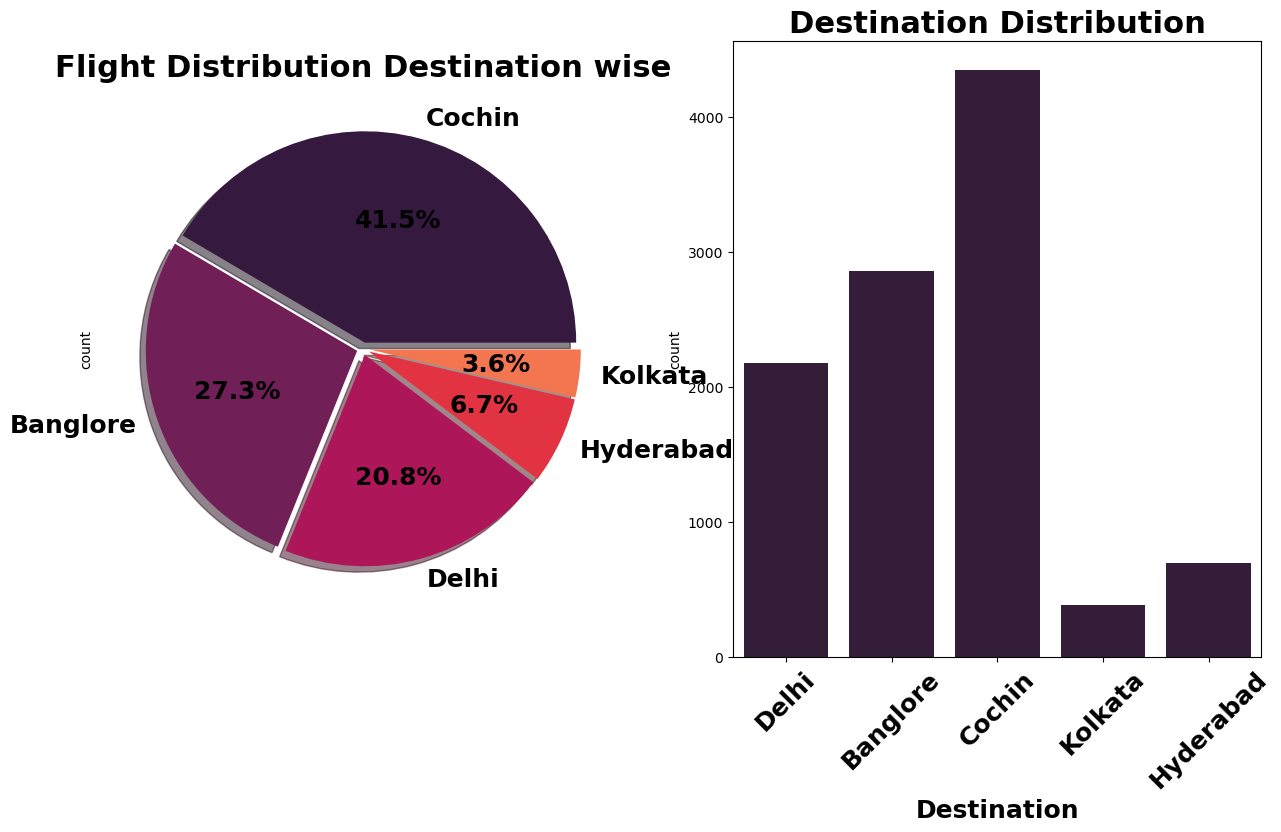

In [22]:
plt.figure(figsize=(15,8))
sns.set_palette('rocket')

plt.subplot(1,2,1)
df['Destination'].value_counts().plot.pie(explode=[0.03,0.03,0.03,0.03,0.03],autopct='%3.1f%%',
                                          textprops ={ 'fontweight': 'bold','fontsize':18},shadow=True)
plt.title('Flight Distribution Destination wise', fontsize=22,fontweight ='bold')

plt.subplot(1,2,2)
sns.countplot(x='Destination',data=df)
plt.title('Destination Distribution',fontsize=22,fontweight ='bold')
plt.xlabel("Destination",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=18,fontweight ='bold',rotation=45)
plt.show()

**Maximum 41.5% Flight lands into cochin followed by Banglore.**

### Airlines VS Source

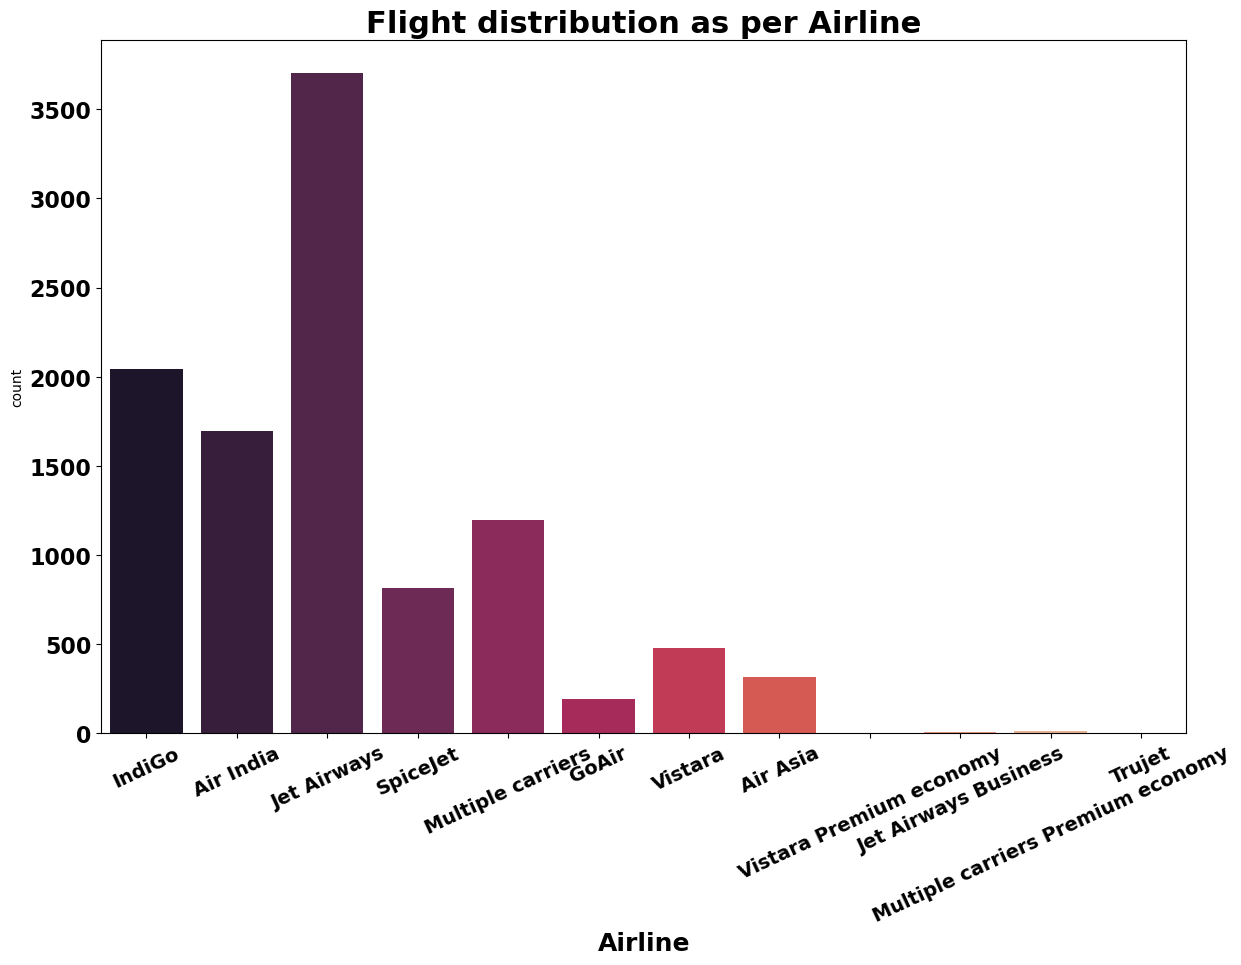

In [23]:
plt.figure(figsize=(14,9))
sns.countplot(x=df['Airline'],  palette='rocket')
plt.title('Flight distribution as per Airline', fontsize=22, fontweight='bold')
plt.xlabel('Airline', fontsize=18,fontweight='bold')
plt.xticks(fontsize=14,fontweight ='bold',rotation=25)
plt.yticks(fontsize=16,fontweight ='bold')
plt.show()

#### Comment :
- jet airways Airline runs highest number of flights out of all flights.
- **Very Few Premium class flights.**
#### Let Visualise Price according to these Airline

## Duration VS Price

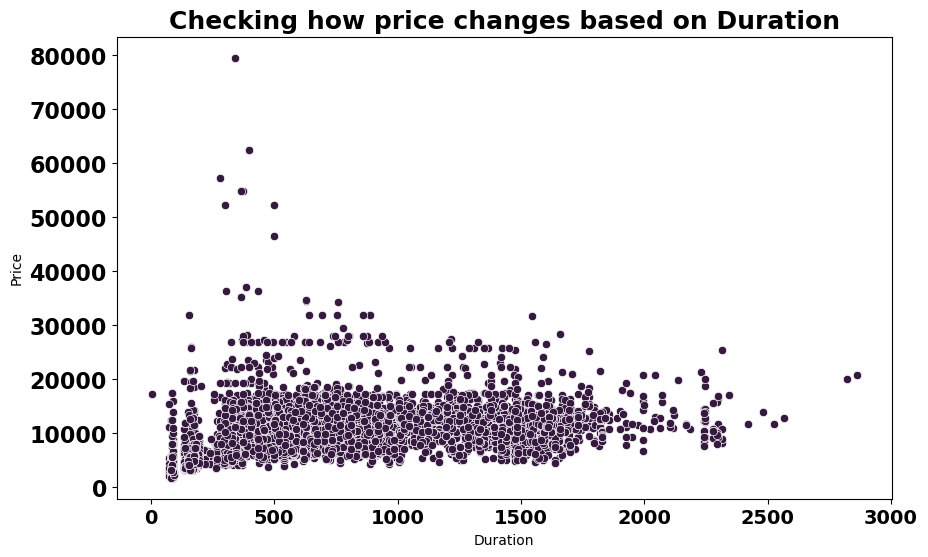

In [24]:
#duration v/s AveragePrice
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Duration', y='Price')
plt.title("Checking how price changes based on Duration",fontsize=18, fontweight='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.yticks(fontsize=16,fontweight ='bold')
plt.show()

**We know that duration( or distance) plays a major role in affecting air ticket prices but we see no such pattern here, as there must be there are other significant factors affecting air fare like type of airline, destination of flight, date of journey of flight(higher if collides with a public holiday)**

### Total Stops VS Price

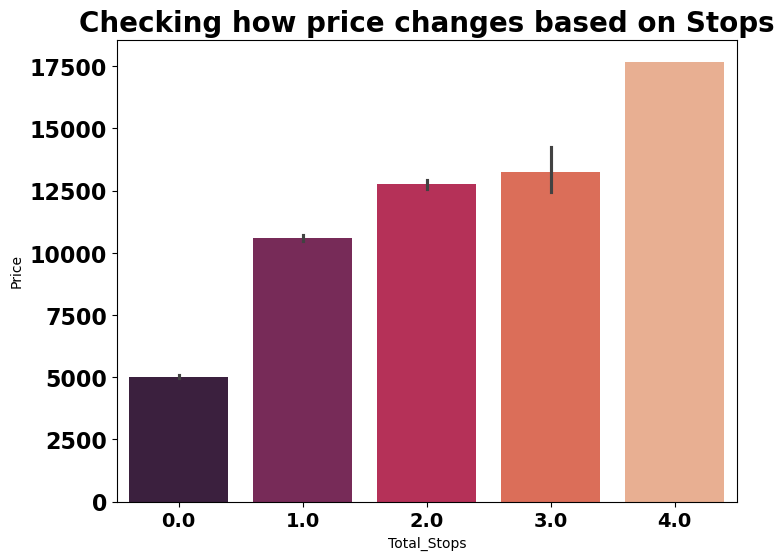

In [25]:
plt.figure(figsize=(8,6))
sns.barplot(x=df["Total_Stops"],y=df["Price"],data=df,palette="rocket")
plt.title("Checking how price changes based on Stops",fontsize=20, fontweight='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.yticks(fontsize=16,fontweight ='bold')
plt.show()

**As a direct/non-stop flight is accounting for fare of only one flight for a trip, its average fair is the least. As the no. of stops/layovers increase, the fare price goes up accounting for no. of flights and due to other resources being used up for the same.**

# Encoding categorical data

In [26]:
# Using Label Encoder on categorical variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in Categorical:
    df[i] = le.fit_transform(df[i])
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,3,0,2,18,170,0,6,3897,24,3,22,20,1,10
1,1,3,0,84,445,2,6,7662,1,5,5,50,13,15
2,4,2,1,118,1140,2,6,13882,9,6,9,25,4,25
3,3,3,0,91,325,1,6,6218,12,5,18,5,23,30
4,3,0,2,29,285,1,6,13302,1,3,16,50,21,35


# Feature selection and Engineering

## 1. Outliers Detection and Removal

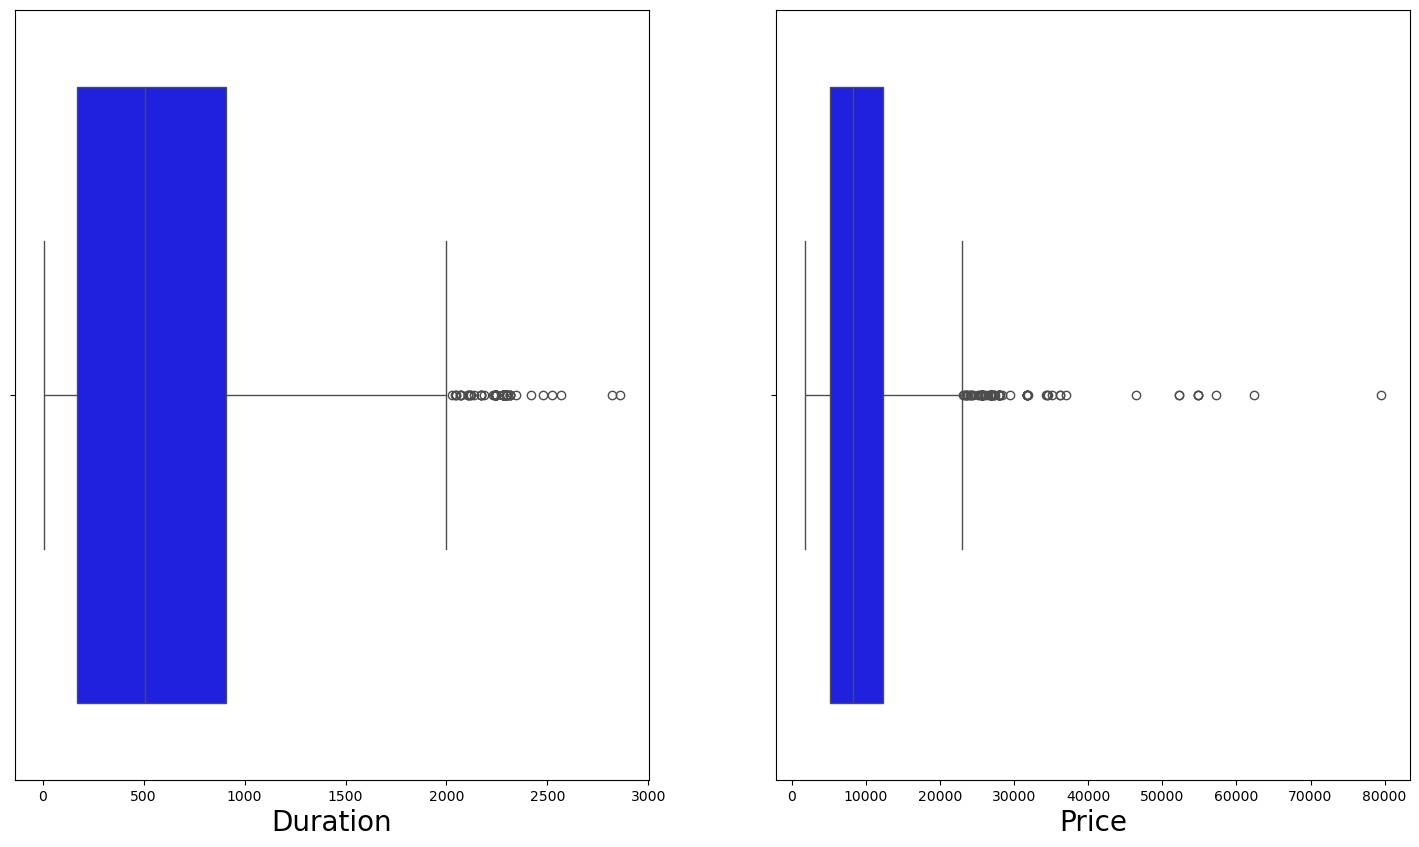

In [27]:
Numerical=['Duration','Price']
plt.figure(figsize=(18,10),facecolor='white')
plotnumber=1

for i in Numerical:
    if plotnumber<=2:
        ax=plt.subplot(1,2,plotnumber)
        sns.boxplot(x=df[i],color='b')
        plt.xlabel(i,fontsize=20)
    plotnumber+=1
plt.show()

<b> From Boxplot we can see outliers exist dataset.</b>

### Outliers removal using Zscore method

In [28]:
from scipy.stats import zscore
z = np.abs(zscore(df))
threshold = 3
df1 = df[(z<3).all(axis = 1)]

print ("Shape of the dataframe before removing outliers: ", df.shape)
print ("Shape of the dataframe after removing outliers: ", df1.shape)
print ("Percentage of data loss post outlier removal: ", (df.shape[0]-df1.shape[0])/df.shape[0]*100)

df=df1.copy() # reassigning the changed dataframe name to our original dataframe name

Shape of the dataframe before removing outliers:  (10460, 14)
Shape of the dataframe after removing outliers:  (10256, 14)
Percentage of data loss post outlier removal:  1.9502868068833654


## 2. Skewness of features

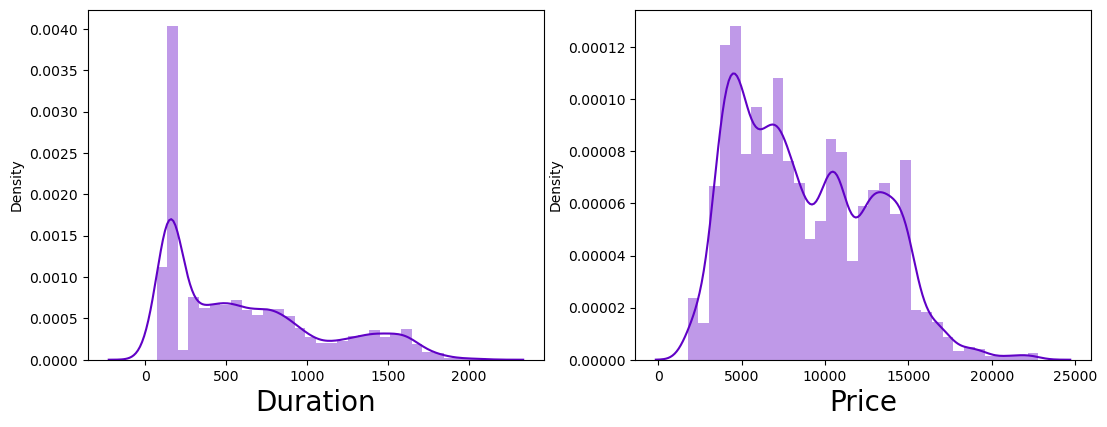

In [29]:
plt.figure(figsize=(20,10),facecolor='white')
sns.set_palette('gnuplot')
plotnum=1
for col in Numerical:
    if plotnum<=6:
        plt.subplot(2,3,plotnum)
        sns.distplot(df[col])
        plt.xlabel(col,fontsize=20)
    plotnum+=1
plt.show()

In [30]:
df.skew()

Airline            0.722682
Source            -0.435507
Destination        0.851034
Route             -0.487899
Duration           0.821698
Total_Stops        0.233264
Additional_Info   -0.722013
Price              0.444590
Journey_Day        0.113066
Journey_Month     -0.410611
Dep_Hour           0.097027
Dep_Min            0.177800
Arrival_Hour      -0.372715
Arrival_Min        0.106683
dtype: float64

In [31]:
df['Duration'] = np.log1p(df['Duration'])

#### Checking skewness after transformation.

In [32]:
df['Duration'].skew()

np.float64(-0.14569614272921294)

## Standard Scaling

In [33]:
# Splitting data in target and dependent feature
X = df.drop(['Price'], axis =1)
Y = df['Price']

In [34]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scale = scaler.fit_transform(X)

# Machine Learning Model Building

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  Ridge
from sklearn.linear_model import  Lasso

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y, random_state=42, test_size=.33)
print('Training feature matrix size:',X_train.shape)
print('Training target vector size:',Y_train.shape)
print('Test feature matrix size:',X_test.shape)
print('Test target vector size:',Y_test.shape)

Training feature matrix size: (6871, 13)
Training target vector size: (6871,)
Test feature matrix size: (3385, 13)
Test target vector size: (3385,)


### Finding best Random state

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
maxR2_score=0
maxRS=0
for i in range(1,500):
    X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y, random_state=i, test_size=.33)
    lin_reg=LinearRegression()
    lin_reg.fit(X_train,Y_train)
    y_pred=lin_reg.predict(X_test)
    R2=r2_score(Y_test,y_pred)
    if R2>maxR2_score:
        maxR2_score=R2
        maxRS=i
print('Best R2 Score is', maxR2_score ,'on Random_state', maxRS)

Best R2 Score is 0.5533798011872914 on Random_state 30


## Linear Regression Base Model

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y, random_state=30, test_size=.33)
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_pred=lr.predict(X_test)


### Linear Regression Evaluation Matrix

In [42]:
print('Error :')
print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
print('Mean squared error :', mean_squared_error(Y_test,y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
print('\n')
from sklearn.metrics import r2_score
print('R2 Score :')
print(r2_score(Y_test,y_pred,multioutput='variance_weighted'))

 Error :
Mean absolute error : 2117.0102558176354
Mean squared error : 7327354.864766263
Root Mean Squared Error: 2706.9087285622068


 R2 Score :
0.5533798011872914


### Applying other ML Models

In [49]:
lr=LogisticRegression()
rf = RandomForestRegressor()
dtc = DecisionTreeRegressor()
adb=AdaBoostRegressor()
etc=ExtraTreesClassifier()
svc=SVC()
knn=KNeighborsClassifier(n_neighbors = 18)

model = [lr,rf,knn,dtc,adb,svc,etc]

for m in model:
    m.fit(X_train,Y_train)
    m.score(X_train,Y_train)
    y_pred = m.predict(X_test)
    print('\n')                                        
    print('Error of ', m, ':')
    print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
    print('Mean squared error :', mean_squared_error(Y_test,y_pred))
    print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
    print('\n')

    print('R2 Score :')
    print(r2_score(Y_test,y_pred)) 
    print('='*50)



 Error of  LogisticRegression() :
Mean absolute error : 1437.1825701624816
Mean squared error : 7138763.080945347
Root Mean Squared Error: 2671.846380491466


 R2 Score :
0.5648749316319157


 Error of  RandomForestRegressor() :
Mean absolute error : 592.6271090501981
Mean squared error : 1260539.9040145783
Root Mean Squared Error: 1122.737682637658


 R2 Score :
0.9231670100694239


 Error of  KNeighborsClassifier(n_neighbors=18) :
Mean absolute error : 1557.8806499261448
Mean squared error : 7705644.229837518
Root Mean Squared Error: 2775.9042184192017


 R2 Score :
0.5303221392403772


 Error of  DecisionTreeRegressor() :
Mean absolute error : 667.7942392909897
Mean squared error : 2125693.252363368
Root Mean Squared Error: 1457.9757379199998


 R2 Score :
0.8704337976654493


 Error of  AdaBoostRegressor() :
Mean absolute error : 2177.2766848587544
Mean squared error : 6554228.097982513
Root Mean Squared Error: 2560.1226724480434


 R2 Score :
0.6005037683843406


 Error of  SVC(

In [53]:
# Cross Validation
model = [lr,rf,knn,dtc,adb,svc]

for m in model:
    score = cross_val_score(m, X_scale, Y, cv =5)
    print('\n')
    print('Cross Validation Score :',m,":")
    print("Mean CV Score :",score.mean())
    print('='*50)



Cross Validation Score : LogisticRegression() :
Mean CV Score : 0.41419537657188094


Cross Validation Score : RandomForestRegressor() :
Mean CV Score : 0.922704769922359


Cross Validation Score : KNeighborsClassifier(n_neighbors=18) :
Mean CV Score : 0.3701246384828206


Cross Validation Score : DecisionTreeRegressor() :
Mean CV Score : 0.8694436345918112


Cross Validation Score : AdaBoostRegressor() :
Mean CV Score : 0.6064560919168251


Cross Validation Score : SVC() :
Mean CV Score : 0.42784663592998423


# Hyper Parameter Tuning : GridSearchCV

In [54]:
from sklearn.model_selection import GridSearchCV

rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7,"auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

GCV = GridSearchCV(RandomForestRegressor(),rf_params,verbose =10)

GCV.fit(X_train,Y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
[CV 1/5; 1/320] START max_depth=5, max_features=5, min_samples_split=2, n_estimators=100
[CV 1/5; 1/320] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.701 total time=   0.6s
[CV 2/5; 1/320] START max_depth=5, max_features=5, min_samples_split=2, n_estimators=100
[CV 2/5; 1/320] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.720 total time=   0.9s
[CV 3/5; 1/320] START max_depth=5, max_features=5, min_samples_split=2, n_estimators=100
[CV 3/5; 1/320] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.723 total time=   0.5s
[CV 4/5; 1/320] START max_depth=5, max_features=5, min_samples_split=2, n_estimators=100
[CV 4/5; 1/320] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.700 total time=   0.5s
[CV 5/5; 1/320] START max_depth=5, max_features=5, min_samples_split=2, n_estimators=100
[CV 5/5; 1/

{'max_depth': 15,
 'max_features': 8,
 'min_samples_split': 2,
 'n_estimators': 1000}

In [55]:
GCV.best_params_

{'max_depth': 15,
 'max_features': 8,
 'min_samples_split': 2,
 'n_estimators': 1000}

## Final Regression Model

In [56]:
Final_mod =  RandomForestRegressor(n_estimators=1000 ,min_samples_split= 2, max_depth=15,max_features=8 )
Final_mod.fit(X_train,Y_train)
y_pred=Final_mod.predict(X_test)
print('\n')                                        
print('Error in Final Model :')
print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
print('Mean squared error :', mean_squared_error(Y_test,y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
print('\n')
print('R2 Score of Final Model :')
print(r2_score(Y_test,y_pred)) 
print('\n')



Error in Final Model :
Mean absolute error : 616.2258900310758
Mean squared error : 1172042.7110948586
Root Mean Squared Error: 1082.6092143958772


R2 Score of Final Model :
0.9285611304069317




True Values Vs Predicted Value plot :


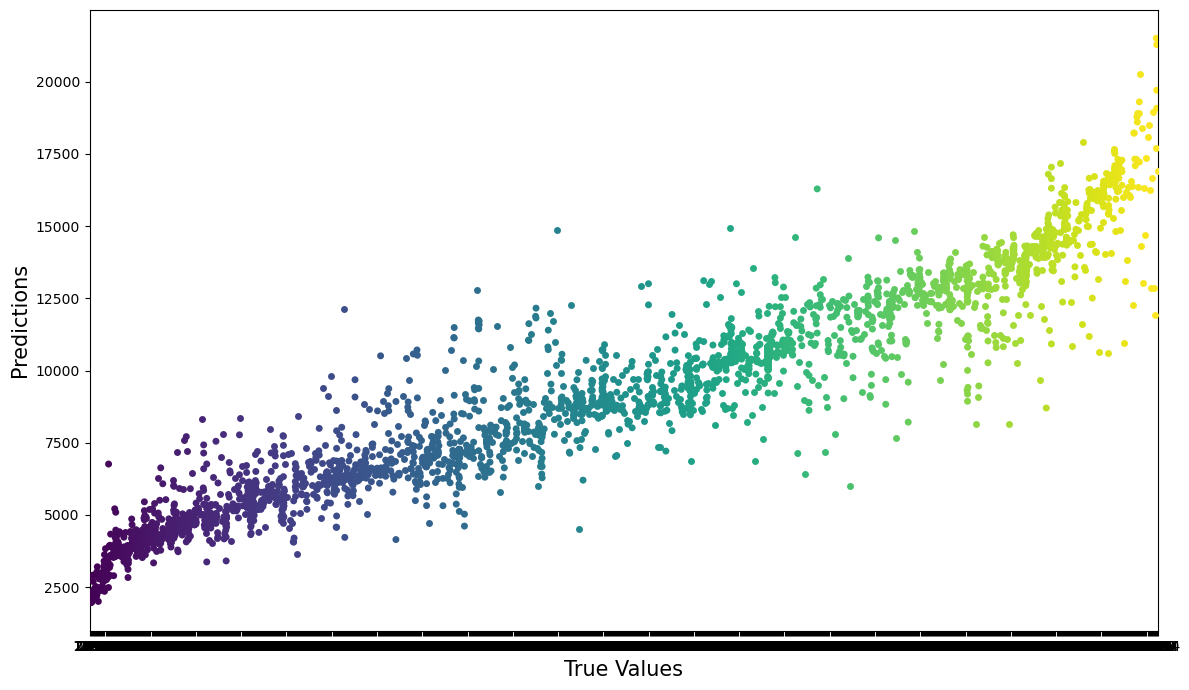

In [58]:
plt.figure(figsize=(12,7))
y_pred=Final_mod.predict(X_test)
sns.swarmplot(x=Y_test.round(2),y=y_pred, palette="viridis")
print('True Values Vs Predicted Value plot :')
plt.xlabel('True Values' , fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.tight_layout()
plt.show()

## Final Regression For Train Dataset Saving Model

In [59]:
import joblib
joblib.dump(Final_mod,'Flight_Price_Final.pkl')

['Flight_Price_Final.pkl']

### Prediction According Final Regression Model

In [60]:
# Loading the saved model
Model = joblib.load("Flight_Price_Final.pkl")

# prediction  DataFrame
actual = np.array(Y_test)
predicted = np.array(Model.predict(X_test))
df_Predicted = pd.DataFrame({"Actual Values":actual,"Predicted Values":predicted},index= range(len(actual)))
df_Predicted 

,Actual Values,Predicted Values
0,10368,10416.179712
1,3543,3554.597309
2,3543,3561.679493
3,4423,4069.776088
4,6144,6443.608745
...,...,...
3380,13764,14407.755473
3381,7408,8595.246059
3382,3597,3607.264798
3383,8073,11397.902541


# ML Model for Test Dataset

In [61]:
test_df = pd.read_excel("Data/Test_set.xlsx")

In [62]:
test_df.shape

(2671, 10)

## Feature Engineering Test Dataset

**We will perform same feature which we perform on Train dataset.**

 **Converting Date and time columns from object type to Datetime type**


**1. Feature Engineering on Date of Journey Columns**

In [64]:
# Extracting Day from Date_of_journey column
test_df['Journey_Day'] = pd.to_datetime(test_df.Date_of_Journey,format="%d/%m/%Y").dt.day

# Extracting Month from Date_of_journey column
test_df['Journey_Month'] = pd.to_datetime(test_df.Date_of_Journey, format="%d/%m/%Y").dt.month

# Dropping Date_of_journey column
test_df.drop("Date_of_Journey",axis=1,inplace=True)

**2. Feature Engineering on 'Duration' Column**

In [65]:
test_df['Duration']=test_df['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)
# convert this column into a numeric
test_df['Duration']=pd.to_numeric(test_df['Duration'])

**3. Feature Engineering on 'Dep_Time' Column**

In [66]:
# Extracting Hours from Dep_Time column
test_df['Dep_Hour']=pd.to_datetime(test_df['Dep_Time']).dt.hour

# Extracting Minutes from Dep_Time column
test_df['Dep_Min']=pd.to_datetime(test_df['Dep_Time']).dt.minute

# Dropping Dep_Time column
test_df.drop("Dep_Time",axis=1,inplace=True)

**4. Feature Engineering on 'Arrival_Time' Column**

In [67]:
# Extracting Arrival_Hour from Arrival_Time column
test_df['Arrival_Hour']=pd.to_datetime(test_df['Arrival_Time']).dt.hour

# Extracting Arrival_Min from Arrival_Time column
test_df['Arrival_Min']=pd.to_datetime(test_df['Arrival_Time']).dt.minute

# Dropping Arruval_Time column
test_df.drop("Arrival_Time",axis=1,inplace=True)

In [68]:
# Replacing "New Delhi" as "Delhi" in Destination column
test_df["Destination"] = test_df["Destination"].replace("New Delhi","Delhi")

# In the column Additional Info, "No Info" and "No info" are one and the same so replace it by "No Info" 
test_df["Additional_Info"] = test_df["Additional_Info"].replace("No info","No Info")

**Checking Duplicate entry**

In [69]:
test_df.duplicated().sum() # This will check the duplicate data for all columns.

np.int64(26)

In [70]:
test_df.drop_duplicates(keep='last',inplace= True)

In [71]:
test_df.shape

(2645, 13)

**Checking Missing Value**

In [72]:
test_df.isnull().sum()

Airline            0
Source             0
Destination        0
Route              0
Duration           0
Total_Stops        0
Additional_Info    0
Journey_Day        0
Journey_Month      0
Dep_Hour           0
Dep_Min            0
Arrival_Hour       0
Arrival_Min        0
dtype: int64

In [73]:
# Spliting data into categorical and Numerical Variable
Numerical = ['Duration', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min']

Categorical = ['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [74]:
# Using Label Encoder on categorical variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in Categorical:
    test_df[i] = le.fit_transform(test_df[i])
test_df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,4,2,1,76,655,0,4,6,6,17,30,4,25
1,3,3,0,65,240,0,4,12,5,6,20,10,20
2,4,2,1,76,1425,0,3,21,5,19,15,19,0
3,6,2,1,76,780,0,4,21,5,8,0,21,0
4,0,0,2,16,170,4,4,24,6,23,55,2,45


### Outliers detection and removal

In [75]:
from scipy.stats import zscore
z = np.abs(zscore(test_df))
threshold = 3
test_df1 = test_df[(z<3).all(axis = 1)]

print ("Shape of the dataframe before removing outliers: ", test_df.shape)
print ("Shape of the dataframe after removing outliers: ", test_df1.shape)
print ("Percentage of data loss post outlier removal: ", (test_df.shape[0]-test_df1.shape[0])/test_df.shape[0]*100)

test_df = test_df1.copy() # reassigning the changed dataframe name to our original dataframe name

Shape of the dataframe before removing outliers:  (2645, 13)
Shape of the dataframe after removing outliers:  (2624, 13)
Percentage of data loss post outlier removal:  0.7939508506616257


In [76]:
test_df.skew()

Airline            0.478323
Source            -0.426633
Destination        0.791714
Route             -0.271087
Duration           0.826742
Total_Stops        0.659810
Additional_Info   -0.835966
Journey_Day        0.196283
Journey_Month     -0.411241
Dep_Hour           0.076868
Dep_Min            0.134720
Arrival_Hour      -0.436527
Arrival_Min        0.106409
dtype: float64

### Standard Scaling

In [77]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
test_df_scale = scaler.fit_transform(test_df)

## Prediction on Test Dataset Using Final Model

In [78]:
# Loading the saved model
Model = joblib.load("Flight_Price_Final.pkl")

In [79]:
# Predicting the flight price from the features of the testing data
Predicted_Price_test = Model.predict(test_df_scale)
Predicted_Price_test

# Creating dataframe for Test data prediction
Prediction = pd.DataFrame()
Prediction['Price'] = Predicted_Price_test
Prediction

,Price
0,12773.590582
1,4812.149894
2,10903.552097
3,10630.801496
4,8237.538603
...,...
2619,8681.005048
2620,9848.530946
2621,9123.393521
2622,12569.402309


**Writeing CSV file of Prediction**

In [80]:
# Saving the Predictions
Prediction.to_csv("Submission_Flight_Price_Data.csv",index=False)